# Food.com Dataset — EDA for RAG Pipeline

100%|██████████| 267M/267M [00:14<00:00, 19.3MB/s] 

Extracting files...


File located at: /Users/gkb/.cache/kagglehub/datasets/shuyangli94/food-com-recipes-and-user-interactions/versions/2/RAW_recipes.csv


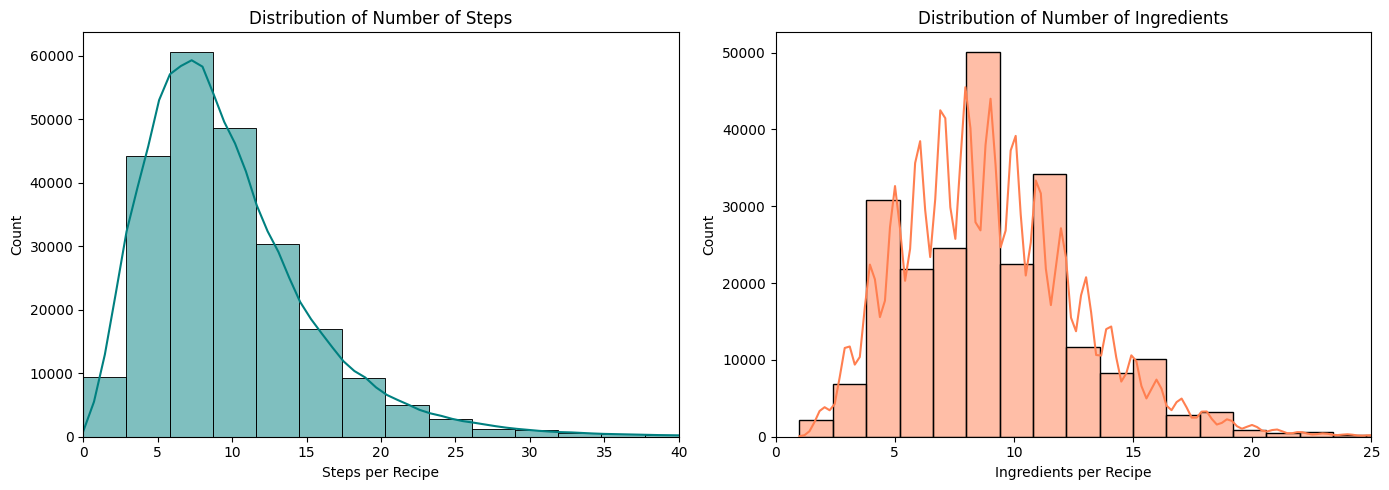

In [1]:
import pandas as pd
import kagglehub
import os
import ast
import matplotlib.pyplot as plt
import seaborn as sns

print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("shuyangli94/food-com-recipes-and-user-interactions")

recipe_file = os.path.join(path, "RAW_recipes.csv")
print(f"File located at: {recipe_file}")

df = pd.read_csv(recipe_file)

df['tags'] = df['tags'].apply(ast.literal_eval)
df['ingredients'] = df['ingredients'].apply(ast.literal_eval)
df['steps'] = df['steps'].apply(ast.literal_eval)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['n_steps'], bins=50, kde=True, color='teal')
plt.title('Distribution of Number of Steps')
plt.xlabel('Steps per Recipe')
plt.xlim(0, 40)

plt.subplot(1, 2, 2)
sns.histplot(df['n_ingredients'], bins=30, kde=True, color='coral')
plt.title('Distribution of Number of Ingredients')
plt.xlabel('Ingredients per Recipe')
plt.xlim(0, 25)

plt.tight_layout()
plt.show()

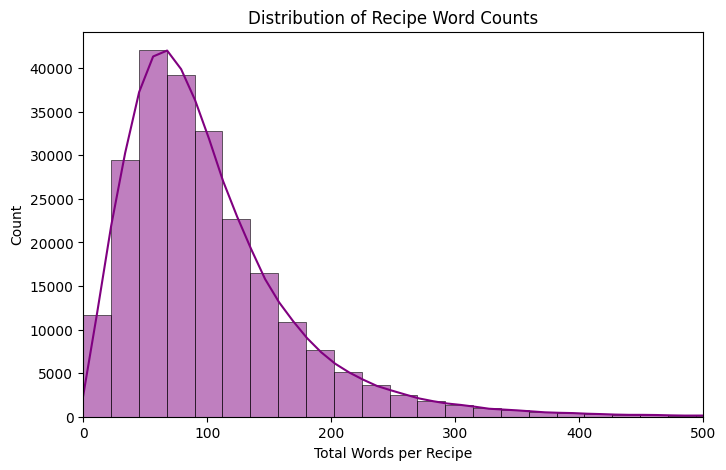

In [2]:
df['word_count'] = df['steps'].apply(lambda x: len(' '.join(x).split()))

plt.figure(figsize=(8, 5))
sns.histplot(df['word_count'], bins=100, color='purple', kde=True)
plt.title('Distribution of Recipe Word Counts')
plt.xlabel('Total Words per Recipe')
plt.xlim(0, 500)
plt.show()

/var/folders/kx/58cjbwzx5jjgn5w_sjz3qk0w0000gn/T/ipykernel_8291/122028732.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tags, x='Count', y='Tag', palette='magma')


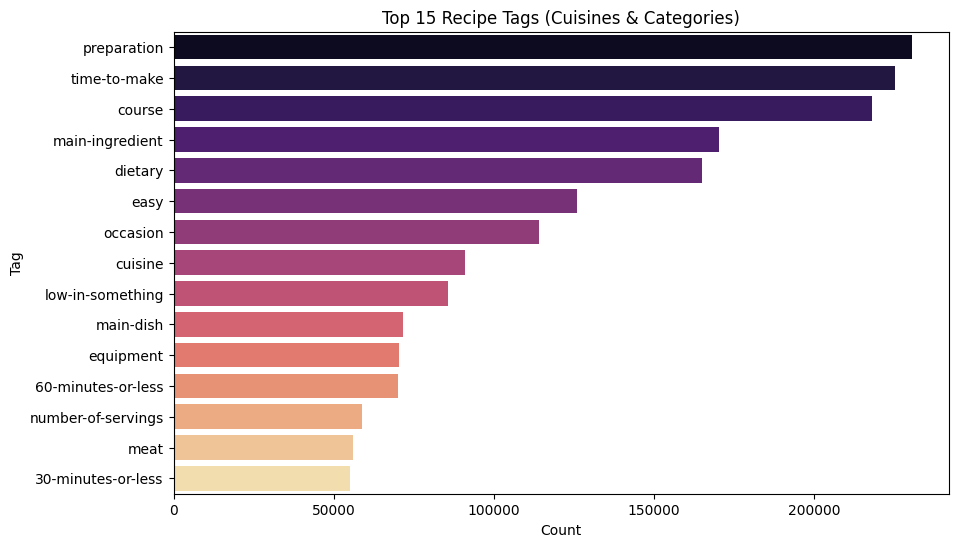

In [3]:
from collections import Counter

all_tags = [tag for tags_list in df['tags'] for tag in tags_list]
top_tags = pd.DataFrame(Counter(all_tags).most_common(15), columns=['Tag', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_tags, x='Count', y='Tag', palette='magma')
plt.title('Top 15 Recipe Tags (Cuisines & Categories)')
plt.show()

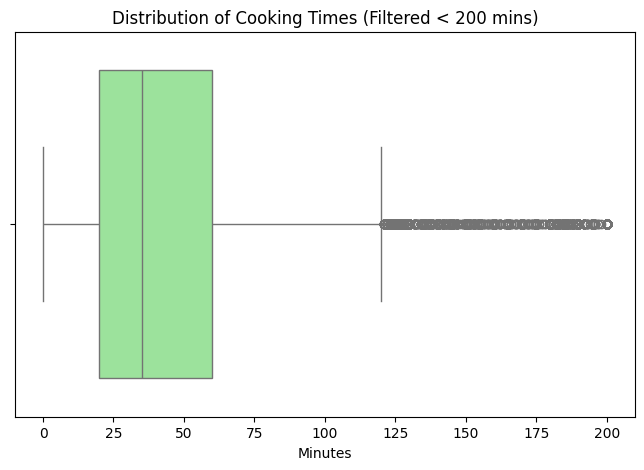

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df[df['minutes'] <= 200]['minutes'], color='lightgreen')
plt.title('Distribution of Cooking Times (Filtered < 200 mins)')
plt.xlabel('Minutes')
plt.show()

In [5]:
# Data quality check
print(f"Total recipes: {len(df):,}")
print(f"\nNull values:")
print(df.isnull().sum())
print(f"\nDuplicate IDs: {df['id'].duplicated().sum()}")
print(f"\nRecipes with 0 steps: {(df['n_steps'] == 0).sum()}")
print(f"\nSummary stats:")
print(df[['n_steps', 'n_ingredients', 'minutes', 'word_count']].describe())

Total recipes: 231,637

Null values:
name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
word_count           0
dtype: int64

Duplicate IDs: 0

Recipes with 0 steps: 1

Summary stats:
             n_steps  n_ingredients       minutes     word_count
count  231637.000000  231637.000000  2.316370e+05  231637.000000
mean        9.765499       9.051153  9.398546e+03     102.081459
std         5.995128       3.734796  4.461963e+06      73.948581
min         0.000000       1.000000  0.000000e+00       0.000000
25%         6.000000       6.000000  2.000000e+01      54.000000
50%         9.000000       9.000000  4.000000e+01      86.000000
75%        12.000000      11.000000  6.500000e+01     130.000000
max       145.000000      43.000000  2.147484e+09    2246.000000


Token count stats:
count    231637.000000
mean        157.980957
std          89.742857
min          14.000000
25%          98.000000
50%         139.000000
75%         195.000000
max        2565.000000
Name: token_count, dtype: float64

Recipes under 100 tokens:  59,381  (25.6%)
Recipes under 500 tokens:  229,929  (99.3%)
Recipes under 1000 tokens: 231,578  (100.0%)
Recipes over 8191 tokens:  0  (exceed embedding limit)


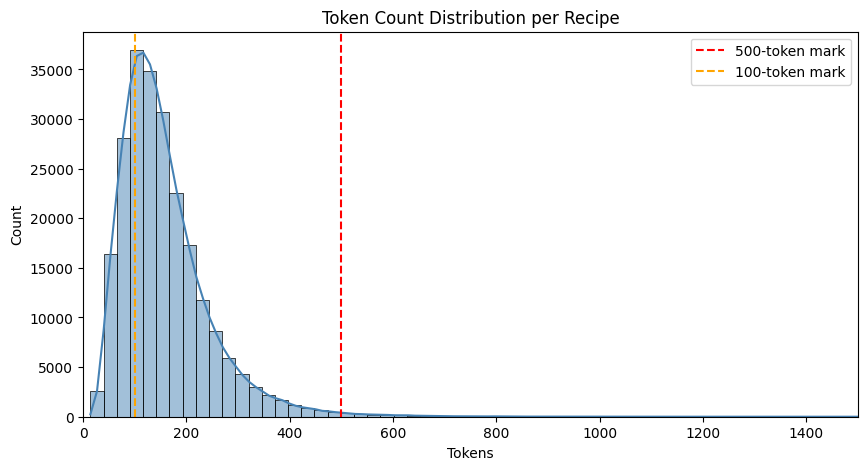

In [6]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")

def format_recipe(row):
    ingredients = ', '.join(row['ingredients'])
    steps = ' '.join(row['steps'])
    return f"Recipe: {row['name']}\nIngredients: {ingredients}\nSteps: {steps}"

df['formatted_text'] = df.apply(format_recipe, axis=1)
df['token_count'] = df['formatted_text'].apply(lambda x: len(enc.encode(x)))

print("Token count stats:")
print(df['token_count'].describe())
print(f"\nRecipes under 100 tokens:  {(df['token_count'] < 100).sum():,}  ({(df['token_count'] < 100).mean():.1%})")
print(f"Recipes under 500 tokens:  {(df['token_count'] < 500).sum():,}  ({(df['token_count'] < 500).mean():.1%})")
print(f"Recipes under 1000 tokens: {(df['token_count'] < 1000).sum():,}  ({(df['token_count'] < 1000).mean():.1%})")
print(f"Recipes over 8191 tokens:  {(df['token_count'] > 8191).sum():,}  (exceed embedding limit)")

plt.figure(figsize=(10, 5))
sns.histplot(df['token_count'], bins=100, color='steelblue', kde=True)
plt.axvline(x=500, color='red', linestyle='--', label='500-token mark')
plt.axvline(x=100, color='orange', linestyle='--', label='100-token mark')
plt.title('Token Count Distribution per Recipe')
plt.xlabel('Tokens')
plt.xlim(0, 1500)
plt.legend()
plt.show()

In [8]:
# Data sample check
for i in range(3):
    row = df.iloc[i]
    print(f"--- Recipe: '{row['name']}' | {row['token_count']} tokens ---")
    print(row['formatted_text'][:400])
    print()

--- Recipe: 'arriba   baked winter squash mexican style' | 181 tokens ---
Recipe: arriba   baked winter squash mexican style
Ingredients: winter squash, mexican seasoning, mixed spice, honey, butter, olive oil, salt
Steps: make a choice and proceed with recipe depending on size of squash , cut into half or fourths remove seeds for spicy squash , drizzle olive oil or melted butter over each cut squash piece season with mexican seasoning mix ii for sweet squash , drizzle 

--- Recipe: 'a bit different  breakfast pizza' | 116 tokens ---
Recipe: a bit different  breakfast pizza
Ingredients: prepared pizza crust, sausage patty, eggs, milk, salt and pepper, cheese
Steps: preheat oven to 425 degrees f press dough into the bottom and sides of a 12 inch pizza pan bake for 5 minutes until set but not browned cut sausage into small pieces whisk eggs and milk in a bowl until frothy spoon sausage over baked crust and sprinkle with cheese p

--- Recipe: 'all in the kitchen  chili' | 116 tokens ---
R

In [9]:
import json, os

dev_df = df[(df['n_steps'] >= 3) & (df['token_count'] > 50)].head(10000).copy()
print(f"Dev subset size: {len(dev_df):,} recipes")
print(f"Token count stats for dev subset:")
print(dev_df['token_count'].describe())

# Export to JSONL
os.makedirs('../data/processed', exist_ok=True)
output_path = '../data/processed/recipes_dev.jsonl'

with open(output_path, 'w') as f:
    for _, row in dev_df.iterrows():
        record = {
            'id': row['id'],
            'name': row['name'],
            'ingredients': row['ingredients'],
            'steps': row['steps'],
            'formatted_text': row['formatted_text'],
            'token_count': int(row['token_count'])
        }
        f.write(json.dumps(record) + '\n')

print(f"\nSaved to {output_path}")

Dev subset size: 10,000 recipes
Token count stats for dev subset:
count    10000.000000
mean       163.479800
std         91.522299
min         51.000000
25%        104.000000
50%        143.000000
75%        197.000000
max       1986.000000
Name: token_count, dtype: float64

Saved to ../data/processed/recipes_dev.jsonl


For the primary knowledge base of our RAG-enabled cooking assistant, we are utilizing the Food.com Recipes dataset sourced from Kaggle. This extensive corpus contains approximately 231,637 unique recipes, each rich with metadata including ingredient lists, structured preparation steps, and categorical tags. This dataset is particularly well-suited for our objectives because its scale allows us to test the robustness of our vector database, while its variety ensures the assistant can handle a wide range of culinary queries from simple snacks to complex multi-stage meals. To ensure the highest quality of responses, we have also integrated a manually curated subset of NYT Cooking recipes to provide a benchmark of professional culinary standards. Furthermore, the system is designed to handle User-Uploaded PDFs at runtime, which transforms the tool from a general search engine into a truly personalized kitchen assistant capable of "learning" a user's private collection of family recipes.

Our Exploratory Data Analysis (EDA) of the Food.com corpus revealed several key characteristics that directly influence our technical approach. When examining recipe complexity, we found that the distribution of preparation steps follows a clear unimodal curve, peaking between 5 and 10 steps per recipe. This is an ideal finding for a RAG architecture; it suggests that individual recipes are concise enough to be stored as discrete "chunks" in our vector database without exceeding the context windows of modern large language models. Similarly, the distribution of ingredients shows that most recipes utilize between 5 and 12 items. This level of density provides sufficient detail for the assistant to perform intelligent ingredient lookups and substitutions without overwhelming the user with excessive data.

Beyond the raw text of the recipes, the dataset’s tagging system provides a critical layer for personalized retrieval. Our analysis of the tag frequency identifies a high prevalence of dietary and time-based labels, such as "vegetarian," "low-carb," and "60-minutes-or-less". We plan to leverage these tags through metadata filtering, allowing the assistant to narrow down the search space before the generation phase begins. This ensures that if a user asks for a "quick vegan dinner," the system doesn't just find recipes that mention those words, but specifically retrieves documents tagged with those attributes. By combining this structured Kaggle data with our custom Q&A and STT test sets, we have established a grounded environment for evaluating the system’s ability to provide accurate, helpful, and hands-free cooking guidance.